In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("crowd_data.csv")

df.head()

,timestamp,location,people_count,area_size,density,weather,event_type
0,2026-01-01 08:00:00,Stage Area,873,87,10.03,Sunny,Emergency
1,2026-01-01 08:30:00,Gate B,117,44,2.66,Sunny,Concert
2,2026-01-01 09:00:00,Parking,941,75,12.55,Cloudy,Normal
3,2026-01-01 09:30:00,Parking,972,66,14.73,Sunny,Festival
4,2026-01-01 10:00:00,Stage Area,205,50,4.10,Rainy,Festival


In [28]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     1500 non-null   object 
 1   location      1500 non-null   object 
 2   people_count  1500 non-null   int64  
 3   area_size     1500 non-null   int64  
 4   density       1500 non-null   float64
 5   weather       1500 non-null   object 
 6   event_type    1500 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 82.2+ KB


timestamp       0
location        0
people_count    0
area_size       0
density         0
weather         0
event_type      0
dtype: int64

In [29]:


df['timestamp'] = pd.to_datetime(df['timestamp'])

df['peak_hour'] = df['timestamp'].dt.hour.isin([18,19,20])
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

EDA

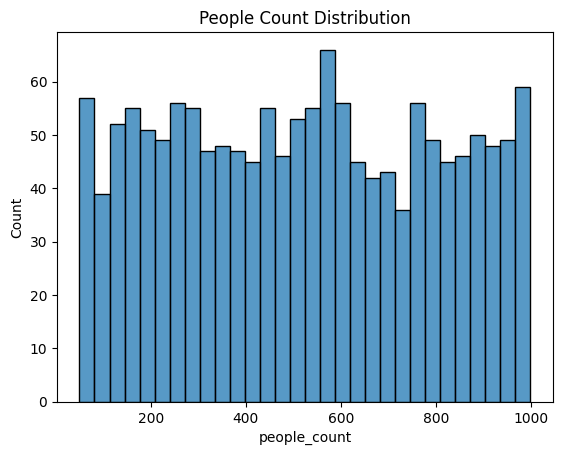

In [30]:
plt.figure()
sns.histplot(df['people_count'], bins=30)
plt.title("People Count Distribution")
plt.show()

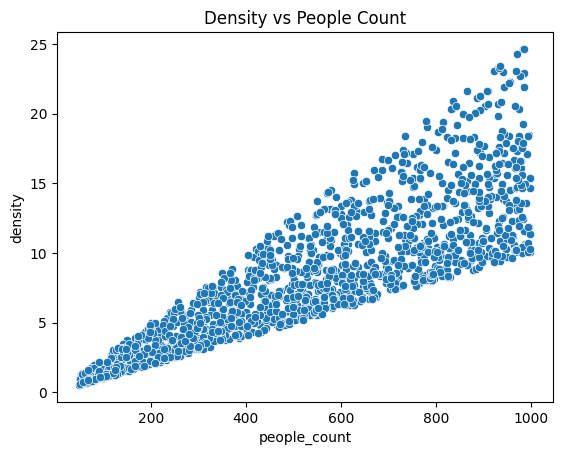

In [31]:
plt.figure()
sns.scatterplot(x='people_count', y='density', data=df)
plt.title("Density vs People Count")
plt.show()

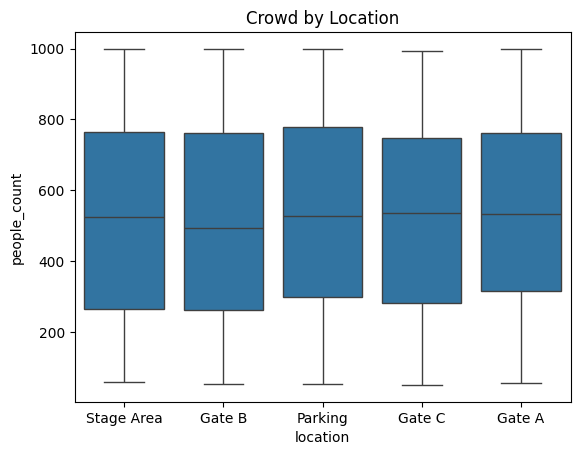

In [32]:
plt.figure()
sns.boxplot(x='location', y='people_count', data=df)
plt.title("Crowd by Location")
plt.show()

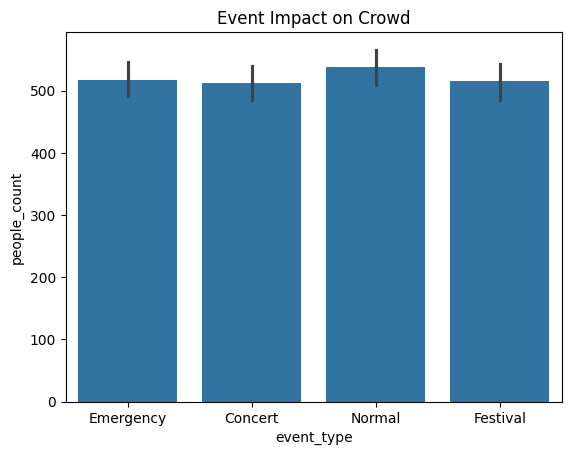

In [33]:
plt.figure()
sns.barplot(x='event_type', y='people_count', data=df)
plt.title("Event Impact on Crowd")
plt.show()

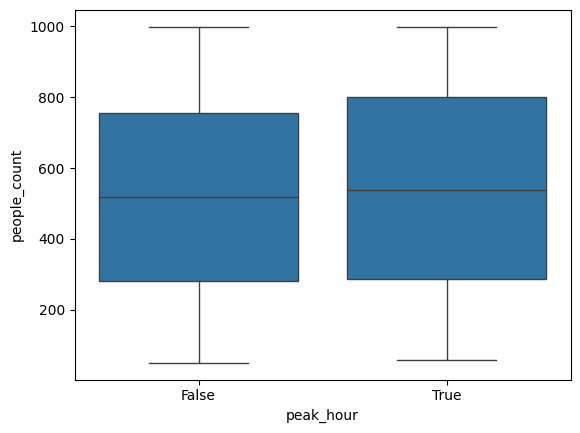

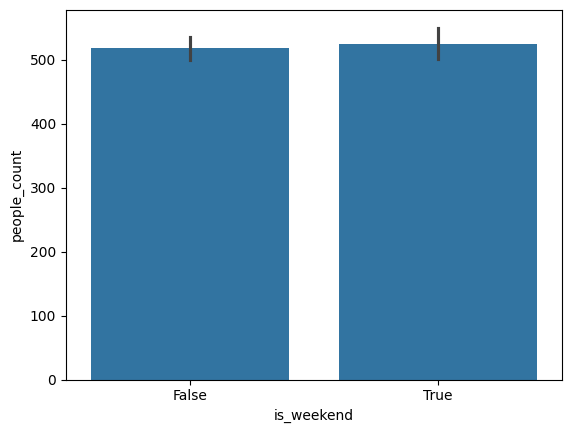

In [34]:
# Peak hour vs crowd
sns.boxplot(x='peak_hour', y='people_count', data=df)
plt.show()

# Weekend vs crowd
sns.barplot(x='is_weekend', y='people_count', data=df)
plt.show()

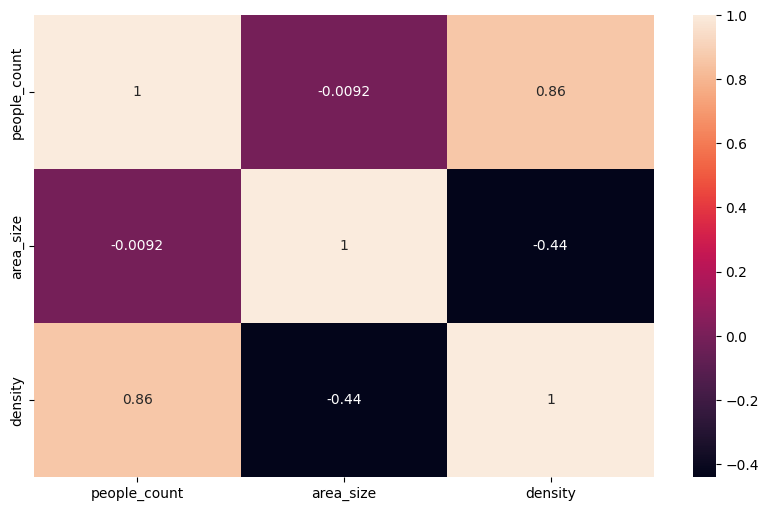

In [35]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

#Red = high crowd
#Blue = low crowd

Feature Engineering

In [36]:
# Time based features
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day

ML Model

In [37]:
df = pd.get_dummies(df, drop_first=True)

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(['density', 'timestamp'], axis=1)
y = df['density']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Hybrid Model

In [40]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression

model1 = RandomForestRegressor(n_estimators=200)
model2 = GradientBoostingRegressor()
model3 = LinearRegression()

hybrid = VotingRegressor([
    ('rf', model1),
    ('gb', model2),
    ('lr', model3)
])

hybrid.fit(X_train, y_train)

accuracy = hybrid.score(X_test, y_test)
print("Hybrid Accuracy:", accuracy)

Hybrid Accuracy: 0.9913247839630038


In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = hybrid.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 0.35061880388861305
R2 Score: 0.9913247839630038


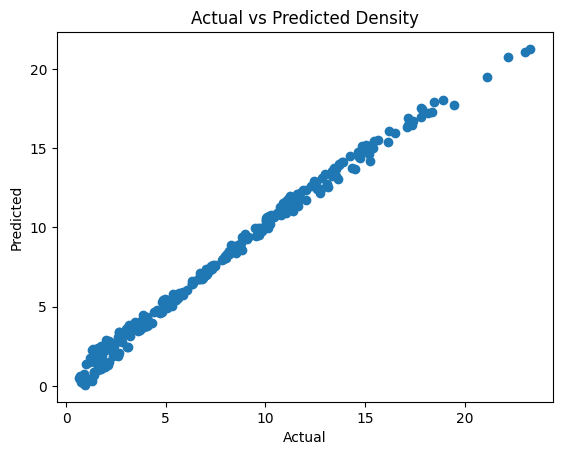

In [ ]:
#Prediction Visualization

import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Density")
plt.show()

In [49]:

import pickle

# Save model
pickle.dump(hybrid, open("model/hybrid_model.pkl", "wb"))

# Save column names
pickle.dump(X.columns, open("model/columns.pkl", "wb"))